# Level 1 & 1.5: Before/After and YoY
### *The default industry approach — and why it fails*

**The starting point — fast, widely used, and systematically wrong**

The instinct after any campaign is to compare the campaign window to what came before, or to the same event last year. Both approaches are fast, require no modeling, and are easy to explain. Both are also systematically wrong in ways that are predictable and directional — they always overstate, and the overstatement scales with how much the business is growing.

**What they cannot do:** Separate three things that are present simultaneously during any seasonal campaign — trend growth already underway before the campaign, organic demand that lifts all channels regardless of campaign decisions, and the paid contribution itself. Before/after and YoY attribute all three to the campaign.

**Why YoY is better but not enough:** Comparing BF 2025 to BF 2024 controls for seasonality — same event, same calendar window. But the November pre-BF baseline grew 61% year-over-year from the trend shift, not from campaigns. That growth is fully embedded in the BF-to-BF delta. Additionally, no two years are perfectly comparable: competitor activity, macro conditions, consumer sentiment, and campaign budget decisions all changed between the two periods. YoY controls for calendar position but absorbs everything else silently.

**Ground truth: $1,340/day = 71.6% of Nov pre-BF baseline**

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from utils import (
    load_dataset, get_treated_series, set_style, save_figure,
    add_intervention_band, add_trend_shift_line, format_date_axis, usd_formatter,
    INTERVENTION_START, INTERVENTION_END, PALETTE, DATA_DIR
)
from generate_data import generate_dataset, TREATED_CHANNEL

set_style()
df, gt = generate_dataset(seed=42, data_dir=DATA_DIR)
ts     = get_treated_series(df)

TRUE_DAILY  = gt['true_increment_usd']
PS_IMM_PRE  = gt['ps_imm_pre_mean_usd']
PS_FULL_PRE = gt['ps_full_pre_mean_usd']
PS_BF_MEAN  = gt['ps_bf_mean_usd']

Saved: dataset.csv  (4,386 rows)


## 1. Naive estimates vs ground truth

In [2]:
pre_mask = (ts.index >= '2025-11-01') & (ts.index < INTERVENTION_START)
bf_mask  = (ts.index >= INTERVENTION_START) & (ts.index <= INTERVENTION_END)
bf24_mask= (ts.index >= '2024-11-28') & (ts.index <= '2024-12-03')

bf_mean       = ts[bf_mask].mean()
bf24_mean     = ts[bf24_mask].mean()
naive_vs_full = bf_mean - ts[ts.index < INTERVENTION_START].mean()
naive_vs_imm  = bf_mean - ts[pre_mask].mean()
yoy           = bf_mean - bf24_mean

print('=== Estimates vs ground truth ($1,340/day) ===')
print(f'Before/After (vs full pre-period): ${naive_vs_full:,.0f}/day  '
      f'({naive_vs_full/TRUE_DAILY:.1f}x overstatement)')
print(f'Before/After (vs Nov 1-26):        ${naive_vs_imm:,.0f}/day  '
      f'({naive_vs_imm/TRUE_DAILY:.1f}x overstatement)')
print(f'YoY (BF 2025 vs BF 2024):          ${yoy:,.0f}/day  '
      f'({yoy/TRUE_DAILY:.1f}x overstatement)')
print(f'True paid increment:               ${TRUE_DAILY:,.0f}/day  (ground truth)')

=== Estimates vs ground truth ($1,340/day) ===
Before/After (vs full pre-period): $2,998/day  (2.2x overstatement)
Before/After (vs Nov 1-26):        $2,370/day  (1.8x overstatement)
YoY (BF 2025 vs BF 2024):          $2,187/day  (1.6x overstatement)
True paid increment:               $1,340/day  (ground truth)


## 2. Bias decomposition

Saved: 01_before_after.png


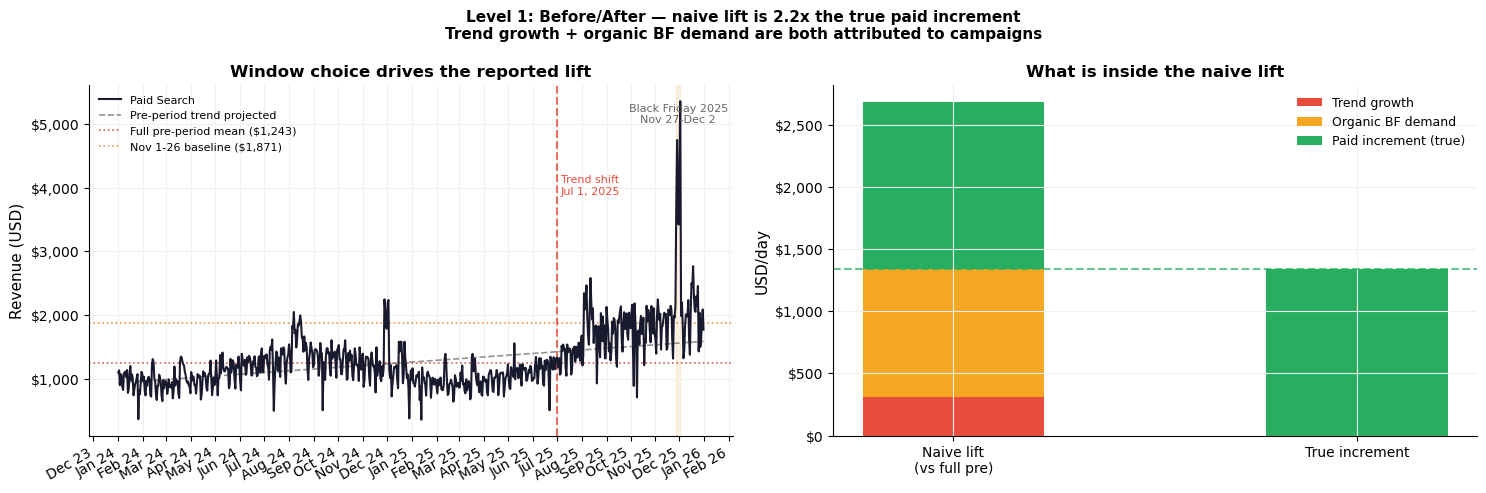

In [3]:
pre_s   = ts[ts.index < INTERVENTION_START]
x_pre   = (pre_s.index - pre_s.index.min()).days.values
slope, intercept, *_ = stats.linregress(x_pre, pre_s.values)
bf_x        = (ts[bf_mask].index - pre_s.index.min()).days.values
trend_proj  = (intercept + slope * bf_x).mean()
trend_comp  = trend_proj - ts[ts.index < INTERVENTION_START].mean()
organic_comp= gt['organic_lift_obs_pct'] / 100 * PS_IMM_PRE

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: time series
x_all      = (ts.index - pre_s.index.min()).days.values
trend_line = intercept + slope * x_all
ax = axes[0]
ax.plot(ts.index, ts, color=PALETTE['actual'], lw=1.5, label='Paid Search', zorder=3)
ax.plot(ts.index, trend_line, color=PALETTE['annotation'], lw=1.2, ls='--',
        alpha=0.7, label='Pre-period trend projected')
ax.axhline(PS_FULL_PRE, color='#c0392b', lw=1.2, ls=':', alpha=0.8,
           label=f'Full pre-period mean (${PS_FULL_PRE:,.0f})')
ax.axhline(PS_IMM_PRE,  color='#e67e22', lw=1.2, ls=':', alpha=0.8,
           label=f'Nov 1-26 baseline (${PS_IMM_PRE:,.0f})')
add_intervention_band(ax)
add_trend_shift_line(ax)
format_date_axis(ax)
ax.set_title('Window choice drives the reported lift')
ax.set_ylabel('Revenue (USD)')
ax.yaxis.set_major_formatter(usd_formatter())
ax.legend(fontsize=8)

# Panel 2: stacked bar
ax = axes[1]
comps = [
    ('Trend growth', max(trend_comp, 0), PALETTE['trend_shift']),
    ('Organic BF demand', max(organic_comp, 0), PALETTE['level2']),
    ('Paid increment (true)', TRUE_DAILY, PALETTE['truth']),
]
bottom = 0
for lbl, v, c in comps:
    ax.bar(['Naive lift\n(vs full pre)'], [v], bottom=bottom, color=c, label=lbl, width=0.45)
    bottom += v
ax.bar(['True increment'], [TRUE_DAILY], color=PALETTE['truth'], width=0.45)
ax.axhline(TRUE_DAILY, color=PALETTE['truth'], lw=1.5, ls='--', alpha=0.7)
ax.set_ylabel('USD/day')
ax.yaxis.set_major_formatter(usd_formatter())
ax.set_title('What is inside the naive lift')
ax.legend(fontsize=9)

plt.suptitle(
    'Level 1: Before/After — naive lift is 2.2x the true paid increment\n'
    'Trend growth + organic BF demand are both attributed to campaigns',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
save_figure(fig, '01_before_after')
plt.show()

## Summary

**Before/After (vs full pre-period):** $2,998/day — 2.2x the true value. Conflates trend growth, organic BF demand, and paid campaigns.

**Before/After (vs Nov 1-26 baseline):** $2,370/day — 1.8x. Still conflates organic demand with paid.

**YoY (BF 2025 vs BF 2024):** $2,187/day — 1.6x. Better than before/after because it controls for seasonality. Still fails because the Nov pre-BF baseline grew 61% YoY — that growth is embedded in the BF delta and cannot be separated from campaign contribution.

**True paid increment:** $1,340/day (ground truth).

---

**Next:** `02_time_series_models.ipynb` — BSTS builds a principled counterfactual but cannot anticipate organic BF demand.